In [1]:
# 📦 Data manipulation
import pandas as pd
import numpy as np 
import joblib

# 📊 Visualization
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# ⚙️ Preprocessing
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [3]:
# 🧪 Model selection & evaluation
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score,
    f1_score, 
    classification_report,
    confusion_matrix,
    roc_curve, 
    auc
)

In [4]:

from sklearn.multiclass import OneVsRestClassifier

#### Loading the preprocessed data

In [5]:
data = pd.read_csv('Stroke_preprocessed.csv')
data

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.600000,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.893237,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.500000,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.400000,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.000000,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...
5104,Female,80.0,1,0,Yes,Private,Urban,83.75,28.893237,never smoked,0
5105,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.000000,never smoked,0
5106,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.600000,never smoked,0
5107,Male,51.0,0,0,Yes,Private,Rural,166.29,25.600000,formerly smoked,0


#### Train test split

In [6]:
X = data.drop(['stroke'],axis=1)            
y = data['stroke']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y,  random_state=42)

#### Separating numarical and categorical features

In [8]:
data_cat = X.select_dtypes(exclude=[np.number]).columns #selects categorical columns (non-numeric).
data_num = X.select_dtypes(include=np.number).columns     #selects numeric columns (integers, floats).
data_stroke = data['stroke'].copy()




#### Scaling data

In [9]:

#scaler = StandardScaler()
#Scaled_data = data_num.copy()


#Scaled_data = scaler.fit_transform(Scaled_data)
## we wil apply pipeline insted of encodding and scalling 

#### Fixing Text and Categorical Attributes


In [10]:

#cat_encodder = OneHotEncoder(sparse_output = False)  #sparse_output=False means it returns a dense NumPy array, not a sparse matrix.

#dat_cat_1hot = cat_encodder.fit_transform(data_cat)

#encoded_cols = cat_encodder.get_feature_names_out(data_cat.columns)                     #Get encoded column names
#df_cat_encoded = pd.DataFrame(dat_cat_1hot, columns=encoded_cols, index=data_cat.index) # Convert to DataFrame


#we wil apply pipeline insted of encodding and scalling 

In [11]:

#data_Conc = pd.concat([data_num, df_cat_encoded, data_stroke ], axis=1)               # Combine encoded data with scalled numeric data
#data_Conc

#features = list(data_Conc.columns)  # Creating a list of our features for future use
#features

#### Pipleline 

In [12]:
# Preprocessing pipeline
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), data_num),
    ("cat", OneHotEncoder(sparse_output=False, handle_unknown='ignore'), data_cat)
])

### Descion tree

In [13]:
from sklearn.tree import DecisionTreeClassifier

In [14]:
tree_clf = DecisionTreeClassifier(random_state=42,class_weight="balanced")

In [15]:
pip_tree_clf = Pipeline([            #Pipeline  applies transform then fit/predict when you call .fit() or .predict().
    ("preprocessor", preprocessor),
    ("classifier ", tree_clf )
    ])


In [16]:
pip_tree_clf.fit(X_train,y_train) # Applies the preprocessing steps (preprocessor) on X_train.
                                  #Passes the transformed data to the DecisionTreeClassifier.

# don’t need to scale or encode X_train and X_test manually.
# as You already wrapped preprocessing (StandardScaler + OneHotEncoder) inside a Pipeline via ColumnTransformer.

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  Index(['gender', 'ever_married', 'work_type', 'Residence_type',
       'smoking_status'],
      dtype='object'))])),
                ('classifier ',
                 DecisionTreeClassifier(class_weight='balanced',
                                        random_state=42))])

In [17]:
pip_tree_clf_prediction = pip_tree_clf.predict(X_test)

In [18]:
print(accuracy_score(pip_tree_clf_prediction, y_test))

0.9227005870841487


In [19]:
print(classification_report(pip_tree_clf_prediction, y_test))

              precision    recall  f1-score   support

           0       0.96      0.96      0.96       975
           1       0.18      0.19      0.19        47

    accuracy                           0.92      1022
   macro avg       0.57      0.57      0.57      1022
weighted avg       0.92      0.92      0.92      1022



### Random forest

In [20]:
from sklearn.ensemble import RandomForestClassifier

In [21]:
rnd_clf = RandomForestClassifier(random_state=42,class_weight="balanced")

In [22]:
pip_rnd_clf = Pipeline([            #Pipeline  applies transform then fit/predict when you call .fit() or .predict().
    ("preprocessor", preprocessor),
    ("classifier ", rnd_clf )
    ])

In [23]:
pip_rnd_clf.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  Index(['gender', 'ever_married', 'work_type', 'Residence_type',
       'smoking_status'],
      dtype='object'))])),
                ('classifier ',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=42))])

In [24]:
pip_rnd_clf_prediction = pip_rnd_clf.predict(X_test)

In [25]:
print(accuracy_score(pip_rnd_clf_prediction, y_test))

0.9510763209393346


In [26]:
print(classification_report(pip_rnd_clf_prediction, y_test))

              precision    recall  f1-score   support

           0       1.00      0.95      0.97      1022
           1       0.00      0.00      0.00         0

    accuracy                           0.95      1022
   macro avg       0.50      0.48      0.49      1022
weighted avg       1.00      0.95      0.97      1022



c:\Users\AFRAAD-PC1\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\AFRAAD-PC1\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\AFRAAD-PC1\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f

### SVM Classifier

In [27]:
from sklearn.svm import SVC

In [28]:
svc_clf = SVC(random_state=42,class_weight="balanced")

In [29]:
pip_svc_clf = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", svc_clf)
])

In [30]:
pip_svc_clf.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  Index(['gender', 'ever_married', 'work_type', 'Residence_type',
       'smoking_status'],
      dtype='object'))])),
                ('classifier', SVC(class_weight='balanced', random_state=42))])

In [31]:
pip_svc_clf_prediction = pip_svc_clf.predict(X_test)

In [32]:
print(classification_report(pip_svc_clf_prediction,y_test))

              precision    recall  f1-score   support

           0       0.75      0.98      0.85       745
           1       0.68      0.12      0.21       277

    accuracy                           0.75      1022
   macro avg       0.72      0.55      0.53      1022
weighted avg       0.73      0.75      0.68      1022



In [33]:
print(accuracy_score(pip_svc_clf_prediction, y_test))

0.7465753424657534


### Logistic Regression

In [34]:
from sklearn.linear_model import LogisticRegression

In [35]:
lreg_clf = LogisticRegression(random_state=42,class_weight="balanced")

In [36]:
pip_lreg_clf = Pipeline([
    ('preprocessor',preprocessor),
    ('classifier',lreg_clf)
])


In [37]:
pip_lreg_clf.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  Index(['gender', 'ever_married', 'work_type', 'Residence_type',
       'smoking_status'],
      dtype='object'))])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', random_state=42))])

In [38]:
pip_lreg_clf_prediction = pip_lreg_clf.predict(X_test) 

In [39]:
print(accuracy_score(pip_lreg_clf_prediction,y_test))

0.738747553816047


In [40]:
print(classification_report(pip_lreg_clf_prediction,y_test))

              precision    recall  f1-score   support

           0       0.74      0.99      0.84       725
           1       0.80      0.13      0.23       297

    accuracy                           0.74      1022
   macro avg       0.77      0.56      0.54      1022
weighted avg       0.75      0.74      0.66      1022



### Visualization of results 

In [41]:
def evaluate_model_df(model, X_train, y_train, X_test, y_test, name="model"): 
    # Predictions (on test set)
    y_pred = model.predict(X_test)
    
    # Metrics as a dictionary
    results = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0)
    }
    
    return results

In [42]:
# Collect results for all models
results = []
results.append(evaluate_model_df(pip_lreg_clf, X_train, y_train, X_test, y_test, "Logistic Regression"))
results.append(evaluate_model_df(pip_svc_clf, X_train, y_train, X_test, y_test, "SVM Classifier"))
results.append(evaluate_model_df(pip_tree_clf, X_train, y_train, X_test, y_test, "Decision Tree"))
results.append(evaluate_model_df(pip_rnd_clf, X_train, y_train, X_test, y_test, "Random Forest"))

# Convert to DataFrame
results_df = pd.DataFrame(results)
print(results_df)

                 Model  Accuracy  Precision  Recall  F1-score
0  Logistic Regression  0.738748   0.134680    0.80  0.230548
1       SVM Classifier  0.746575   0.122744    0.68  0.207951
2        Decision Tree  0.922701   0.191489    0.18  0.185567
3        Random Forest  0.951076   0.000000    0.00  0.000000


In [ ]:
#The main goal = detect as many stroke cases as possible (catch the positives). That means you care most about Recall
#If Recall is low → you’re missing actual stroke cases (false negatives), which is dangerous in a medical-like scenario.
#If Precision is low → you’ll have more false alarms (healthy people flagged as stroke risk). That’s annoying, but not deadly.

<Figure size 600x500 with 0 Axes>

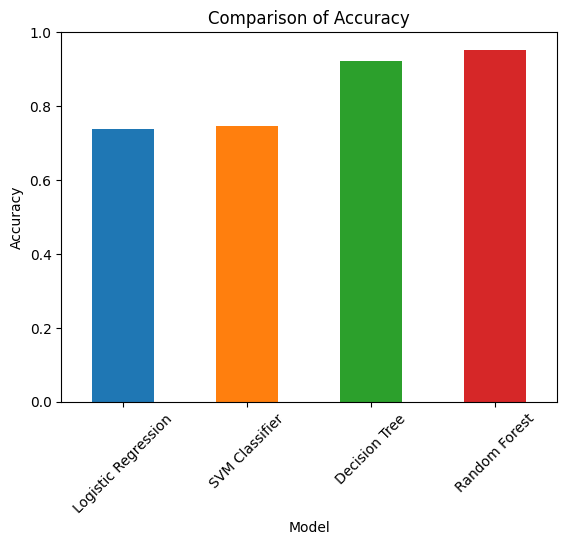

<Figure size 600x500 with 0 Axes>

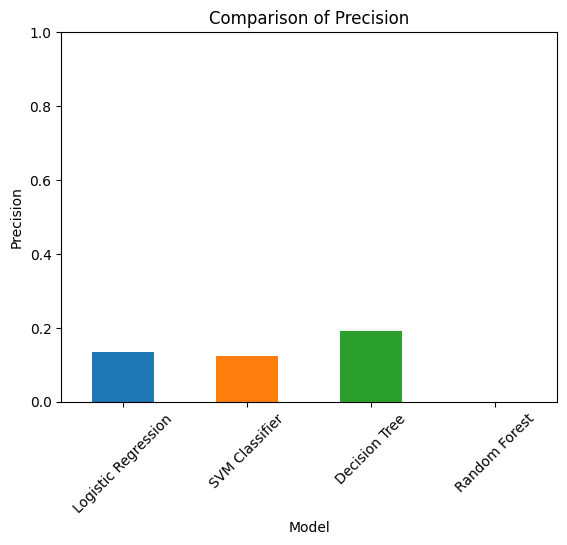

<Figure size 600x500 with 0 Axes>

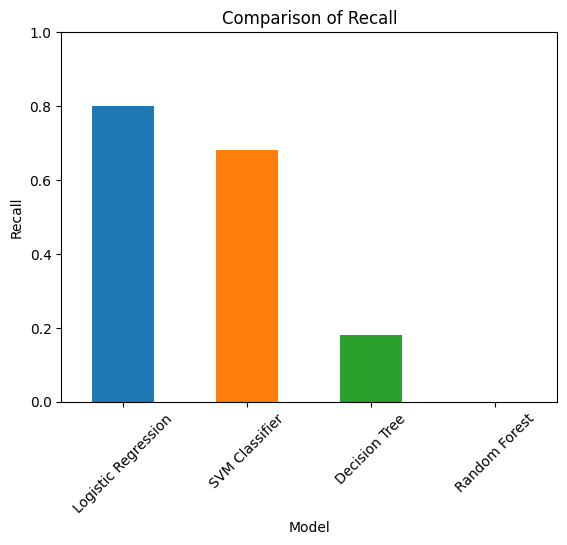

<Figure size 600x500 with 0 Axes>

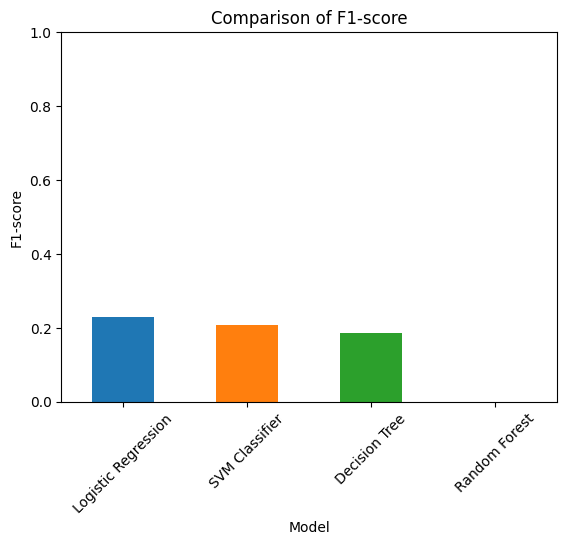

In [43]:
metrics = ["Accuracy", "Precision", "Recall", "F1-score"]

# Unique colors per model
model_colors = dict(zip(results_df["Model"].unique(), plt.cm.tab10.colors))

# Plot each metric separately
for metric in metrics:
    plt.figure(figsize=(6, 5))
    results_df.plot(
        kind="bar",
        x="Model",
        y=metric,
        legend=False,
        color=[model_colors[m] for m in results_df["Model"]]
    )
    plt.title(f"Comparison of {metric}")
    plt.ylabel(metric)
    plt.xlabel("Model")
    plt.ylim(0, 1)  # classification metrics are between 0 and 1
    plt.xticks(rotation=45)
    plt.show()